In [1]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import plotly.express as px
from datetime import datetime
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
play_store_df = play_store_df.drop_duplicates(subset="App")
play_store_df.shape

(9660, 13)

In [6]:
play_store_df["Rating"] = play_store_df["Rating"].fillna(
    play_store_df["Rating"].median()
)

play_store_df["Type"] = play_store_df["Type"].fillna(
    play_store_df["Type"].mode()[0]
)

play_store_df["Content Rating"] = play_store_df[
    "Content Rating"
].fillna(
    play_store_df["Content Rating"].mode()[0]
)

play_store_df["Current Ver"] = play_store_df[
    "Current Ver"
].fillna(
    play_store_df["Current Ver"].mode()[0]
)

play_store_df["Android Ver"] = play_store_df[
    "Android Ver"
].fillna(
    play_store_df["Android Ver"].mode()[0]
)

In [7]:
play_store_df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [8]:
play_store_df = play_store_df[play_store_df["Installs"] != "Free"]
play_store_df["Installs_Num"] = (

    play_store_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(int)

)
play_store_df[
    ["Installs", "Installs_Num"]
].head()

,Installs,Installs_Num
0,"10,000+",10000
1,"500,000+",500000
2,"5,000,000+",5000000
3,"50,000,000+",50000000
4,"100,000+",100000


In [9]:
play_store_df["Reviews"] = pd.to_numeric(
    play_store_df["Reviews"],
    errors="coerce"
)

play_store_df[
    ["Reviews"]
].head()

,Reviews
0,159
1,967
2,87510
3,215644
4,967


In [10]:
play_store_df = play_store_df[
    play_store_df["Size"] != "Varies with device"
].copy()

In [11]:
play_store_df["Size"] = play_store_df["Size"].apply(
    lambda x: float(x[:-1])
    if str(x).endswith("M")
    else float(x[:-1]) / 1024
    if str(x).endswith("k")
    else np.nan
)

In [12]:
play_store_df[["Size"]].head()

,Size
0,19.0
1,14.0
2,8.7
3,25.0
4,2.8


In [13]:
play_store_df["Last Updated"] = pd.to_datetime(
    play_store_df["Last Updated"],
    errors="coerce"
)
play_store_df[["Last Updated"]].head()

,Last Updated
0,2018-01-07
1,2018-01-15
2,2018-08-01
3,2018-06-08
4,2018-06-20


In [14]:
play_store_df["Update_Month"] = (
    play_store_df["Last Updated"]
    .dt.month_name()
)
play_store_df[
    ["Last Updated", "Update_Month"]
].head()

,Last Updated,Update_Month
0,2018-01-07,January
1,2018-01-15,January
2,2018-08-01,August
3,2018-06-08,June
4,2018-06-20,June


In [15]:
filtered_df = play_store_df[
    (play_store_df["Size"] >= 10) &
    (play_store_df["Update_Month"] == "January")
].copy()
filtered_df.shape

(196, 15)

In [16]:
category_summary = (
    filtered_df.groupby("Category")
    .agg(
        Average_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum"),
        Total_Installs=("Installs_Num", "sum")
    )
    .reset_index()
)
category_summary.head()

,Category,Average_Rating,Total_Reviews,Total_Installs
0,ART_AND_DESIGN,4.100000,2167,620000
1,AUTO_AND_VEHICLES,3.900000,22,1000
2,BOOKS_AND_REFERENCE,4.450000,34,1050
3,BUSINESS,4.600000,19,1410
4,COMMUNICATION,4.133333,15398,1011000


In [17]:
category_summary = category_summary[
    category_summary["Average_Rating"] >= 4.0
]
category_summary.shape

(21, 4)

In [18]:
category_summary = (
    category_summary
    .sort_values(
        by="Total_Installs",
        ascending=False
    )
    .head(10)
)
category_summary

,Category,Average_Rating,Total_Reviews,Total_Installs
25,SPORTS,4.337500,1982017,120511100
12,GAME,4.251515,2412245,117291000
9,FAMILY,4.198305,3006890,111221180
7,ENTERTAINMENT,4.300000,869111,21000000
20,PERSONALIZATION,4.440000,156004,15061000
15,LIFESTYLE,4.100000,53376,6171560
6,EDUCATION,4.400000,57645,2000000
26,TOOLS,4.042857,8731,1121110
4,COMMUNICATION,4.133333,15398,1011000
23,SHOPPING,4.200000,9975,1000000


In [19]:
from plotly.subplots import make_subplots

fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)

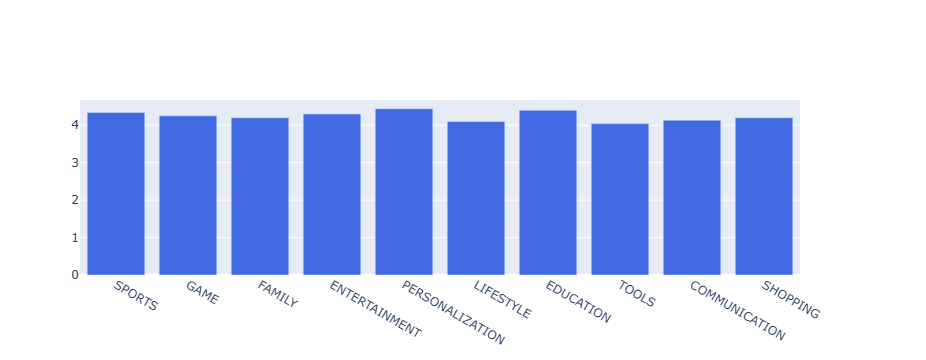

In [20]:
fig.add_trace(
    go.Bar(
        x=category_summary["Category"],
        y=category_summary["Average_Rating"],
        name="Average Rating",
        marker_color="royalblue"
    ),
    secondary_y=False
)

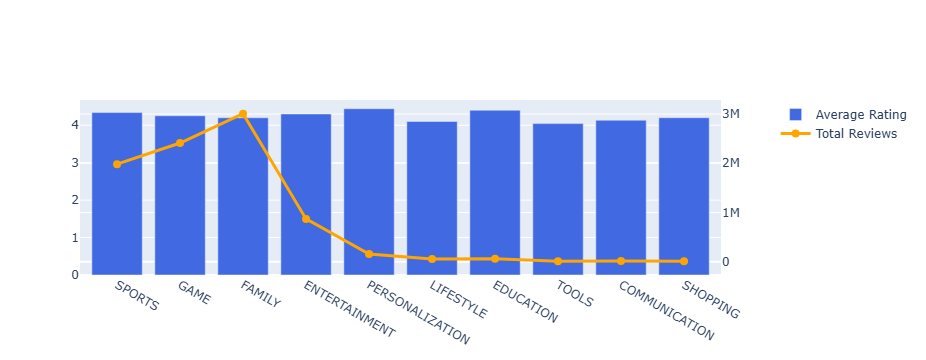

In [21]:
fig.add_trace(
    go.Scatter(
        x=category_summary["Category"],
        y=category_summary["Total_Reviews"],
        name="Total Reviews",
        mode="lines+markers",
        line=dict(color="orange", width=3),
        marker=dict(size=8)
    ),
    secondary_y=True
)

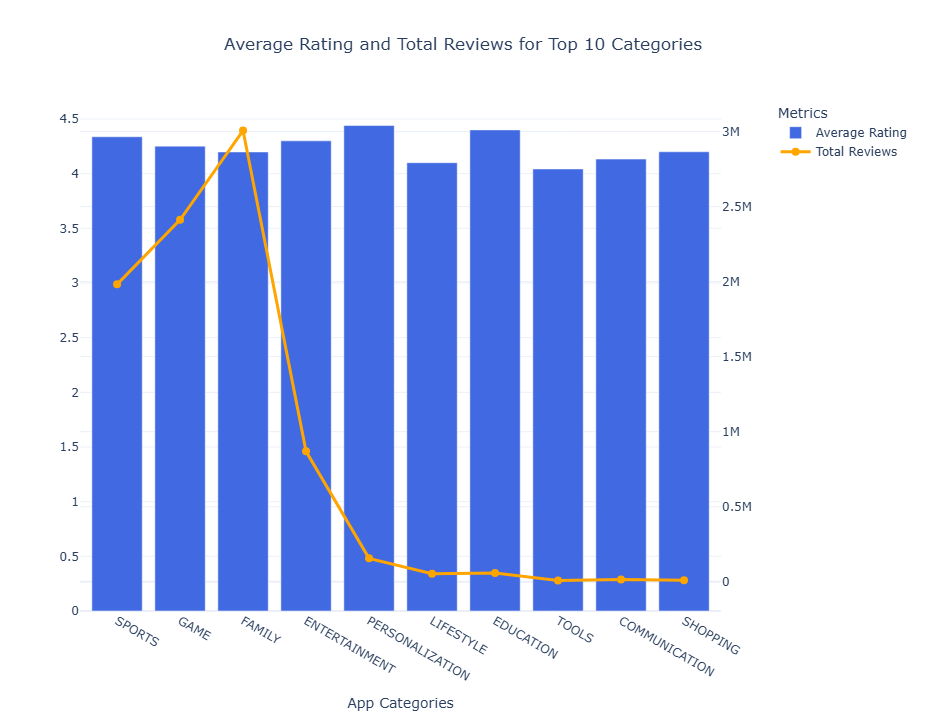

In [22]:
fig.update_layout(
    title={
        "text": "Average Rating and Total Reviews for Top 10 Categories",
        "x": 0.5
    },
    xaxis_title="App Categories",
    template="plotly_white",
    width=1200,
    height=700,
    legend_title="Metrics"
)

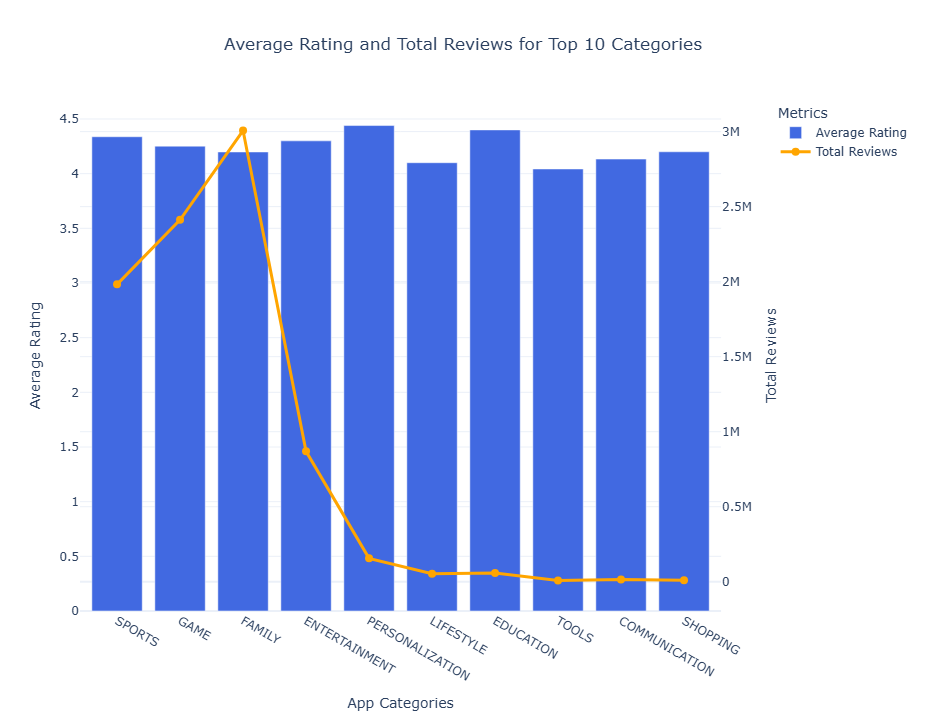

In [23]:
fig.update_yaxes(
    title_text="Average Rating",
    secondary_y=False
)

fig.update_yaxes(
    title_text="Total Reviews",
    secondary_y=True
)

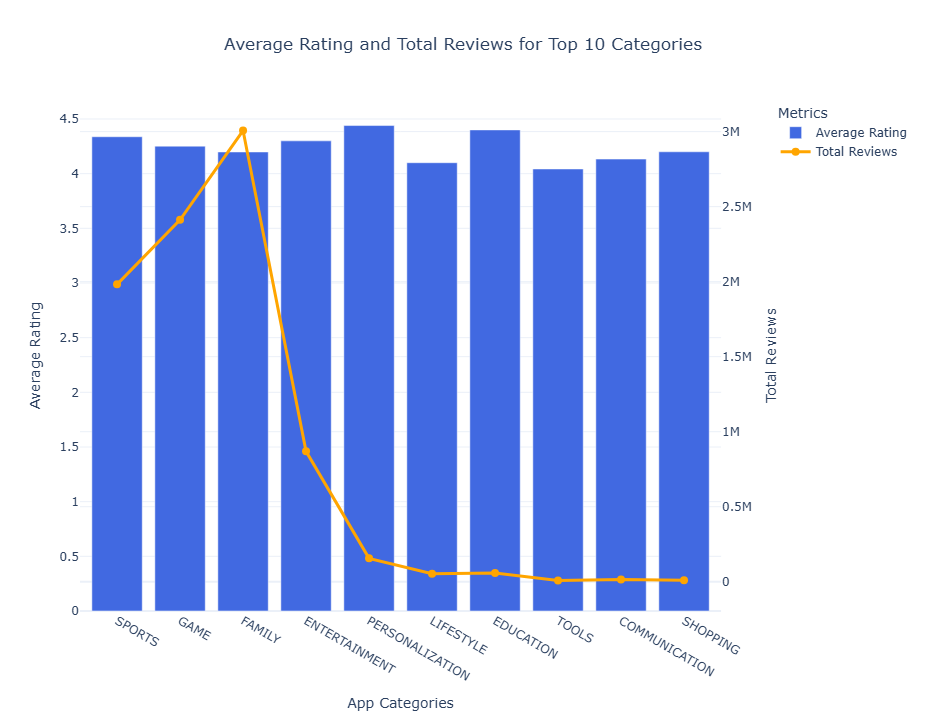

In [24]:
fig.update_traces(
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Value: %{y:,}<extra></extra>"
)

In [25]:
current_hour = datetime.now().hour

if 15 <= current_hour < 17:
    fig.show()
else:
    print(
        "This graph is available only between 3 PM IST and 5 PM IST."
    )

This graph is available only between 3 PM IST and 5 PM IST.


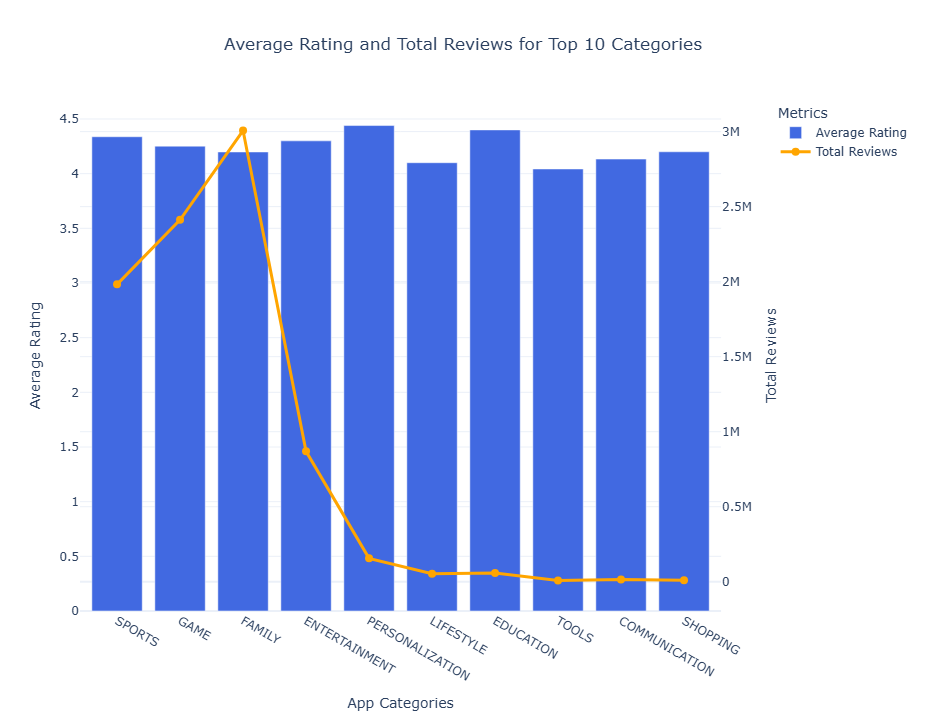

In [26]:
current_hour = 16

if 15 <= current_hour < 17:
    fig.show()
else:
    print(
        "This graph is available only between 3 PM IST and 5 PM IST."
    )